# Deconvolved Data Replication Timing from 10k MNase-seq Windows

April 24, 2024

Compute the replicating timing from the deconvolved MNase-seq 10k windows for each gene.

This will require a tuning of the alpha parameter.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

mnase_analysis_rep1 = MNaseOriginAnalysis(replicate=1)
mnase_analysis_rep1.compute_bin_curves_and_expression_correlations()
mnase_analysis_rep1.compute_replication_timing()

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:15.976


In [5]:
mnase_analysis_rep2 = MNaseOriginAnalysis(replicate=2)
mnase_analysis_rep2.compute_bin_curves_and_expression_correlations()
mnase_analysis_rep2.compute_replication_timing()

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:24.297


In [6]:
mnase_analysis_rep1.load_posteriors_for_timing()
mnase_analysis_rep2.load_posteriors_for_timing()

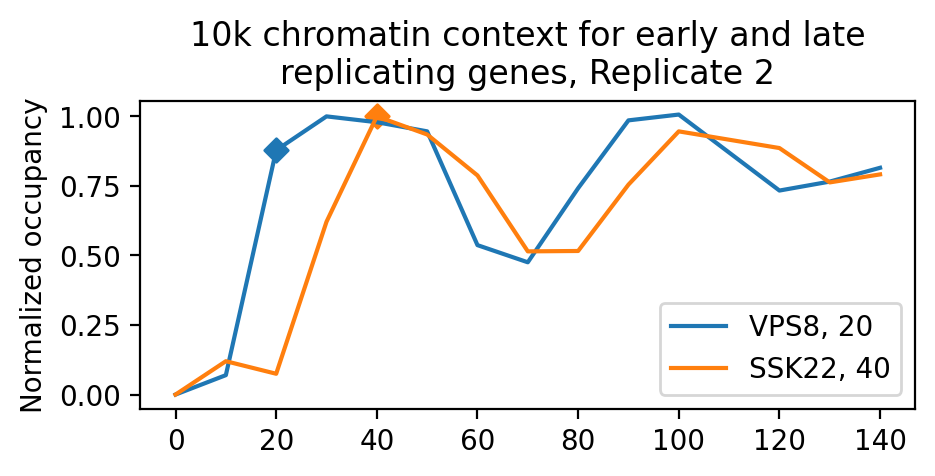

In [15]:
mnase_analysis_rep2.plot_normalized_bin_curves(['VPS8', 'SSK22'])

In [24]:
from src.deconv_replication_timing import DeconvReplicationProfileAnalysis

deconv_rep_analysis = DeconvReplicationProfileAnalysis(mnase_analysis_rep1, mnase_analysis_rep2)

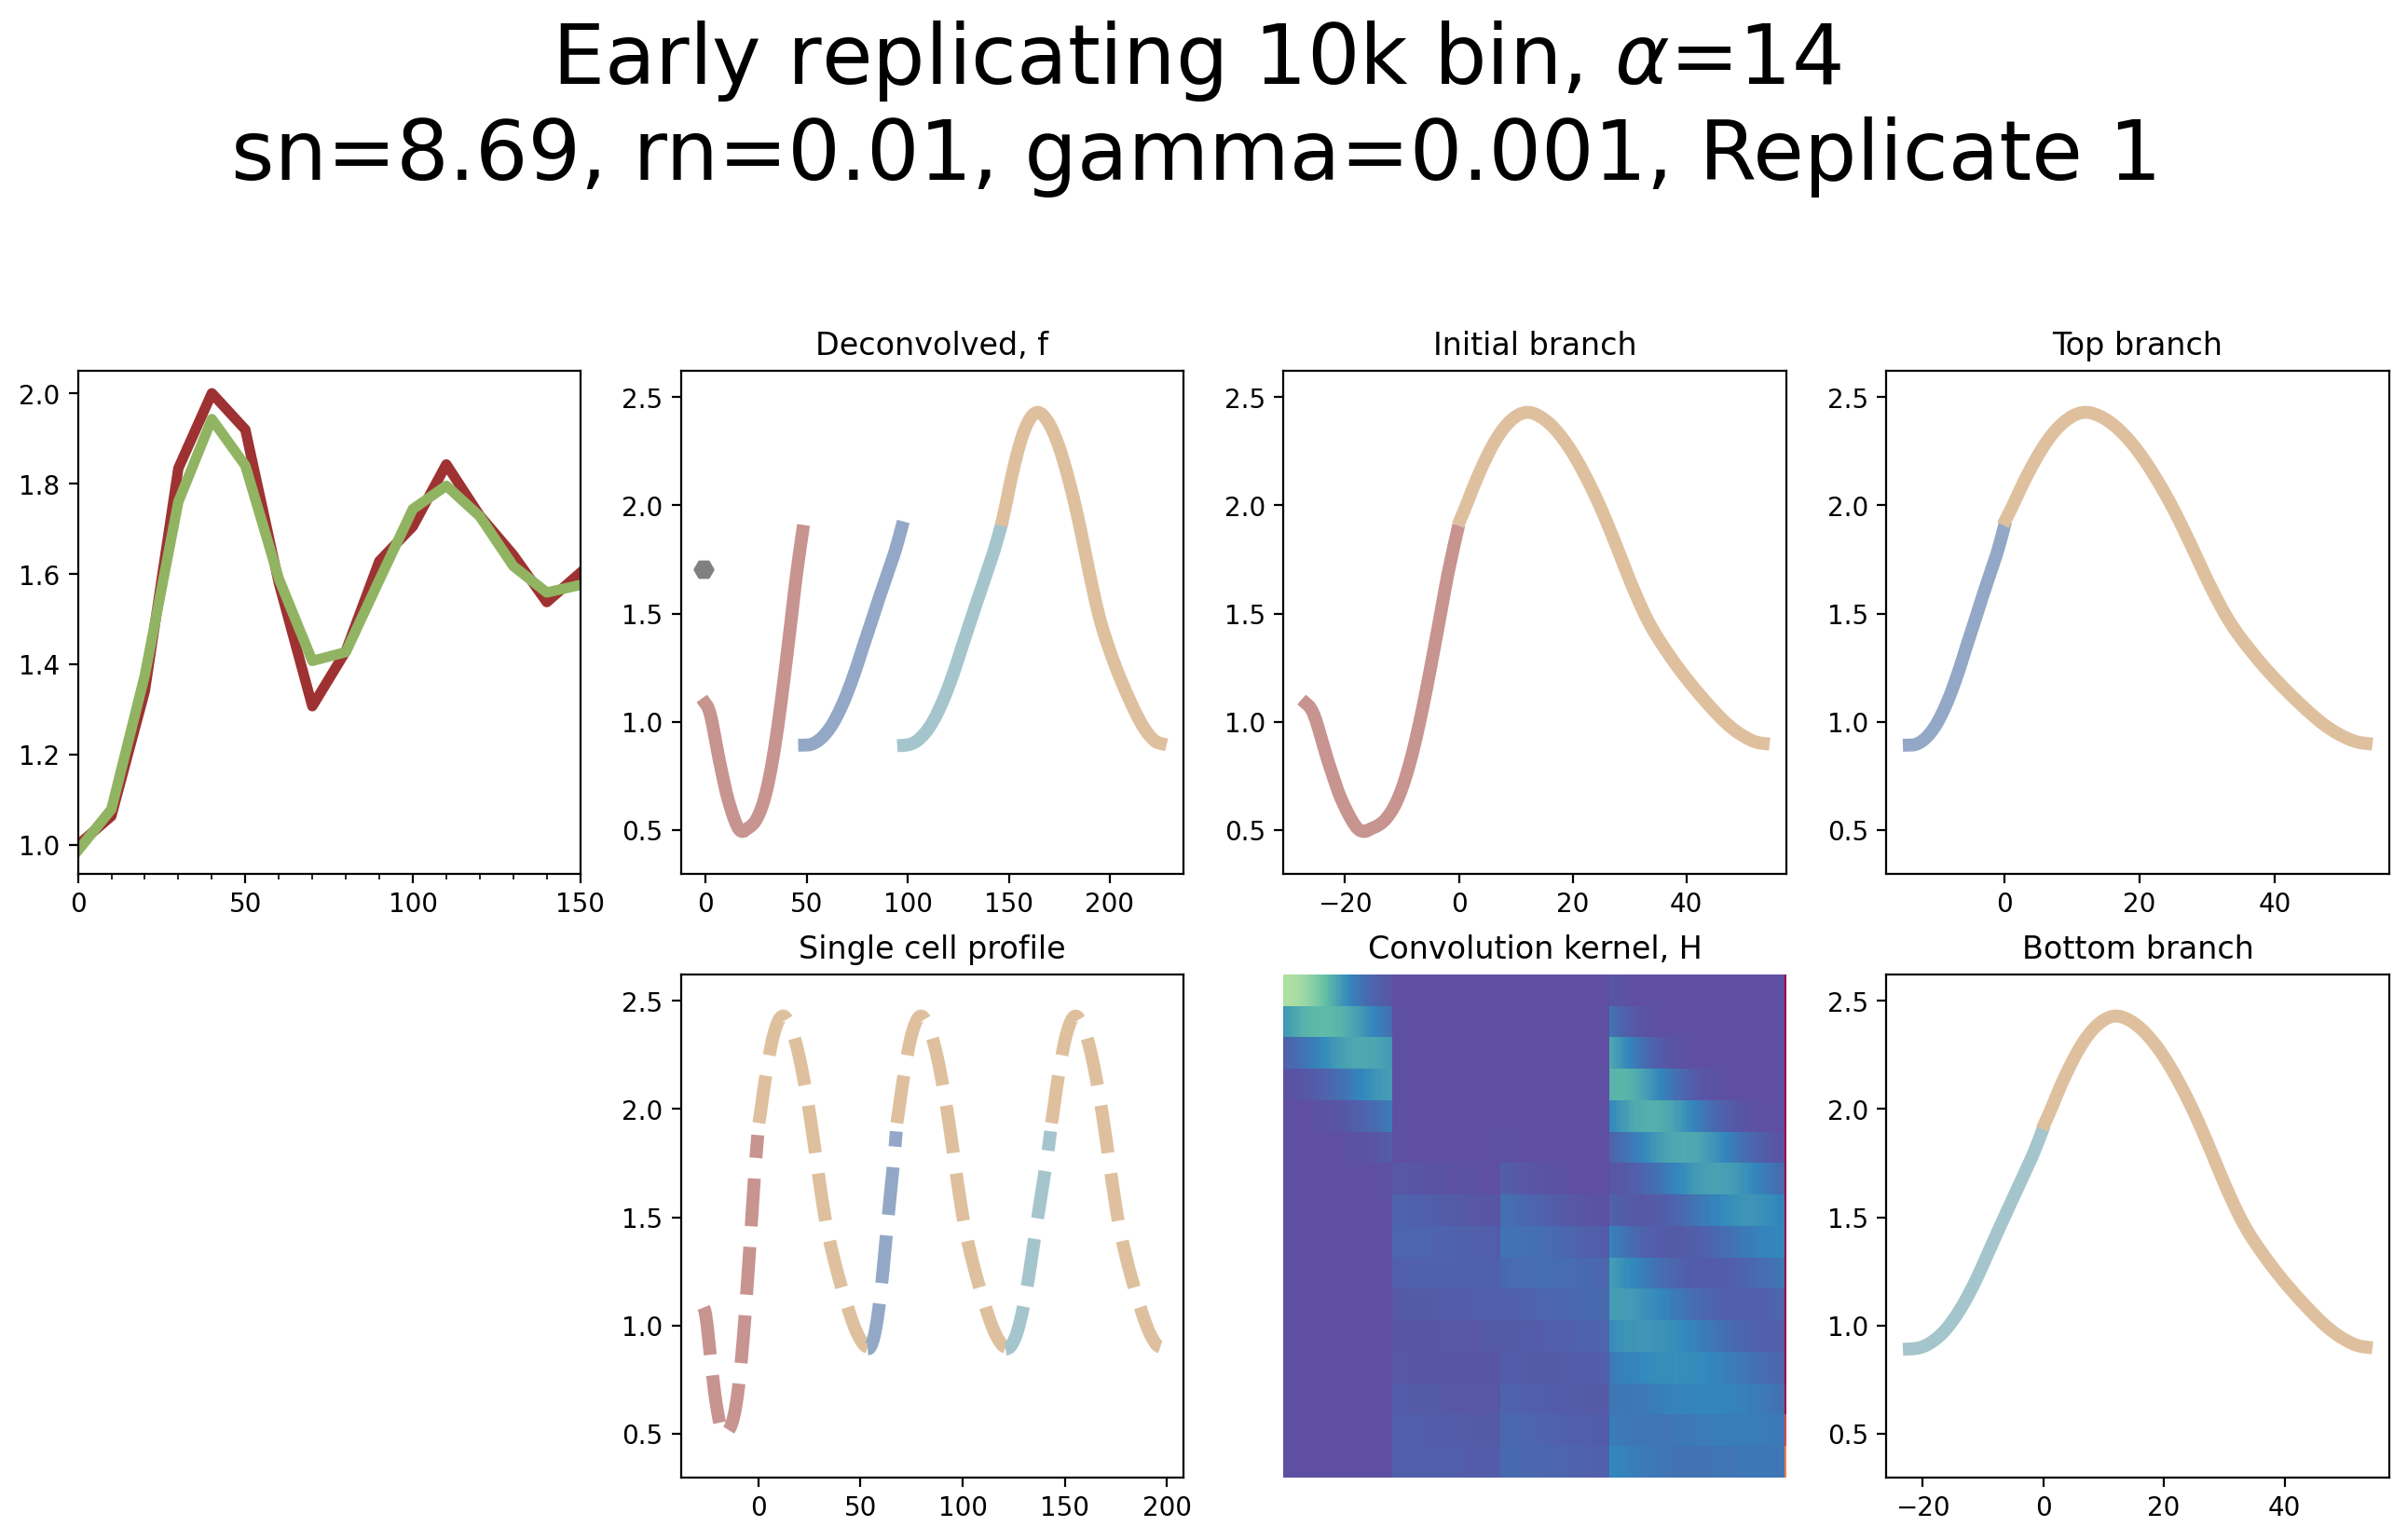

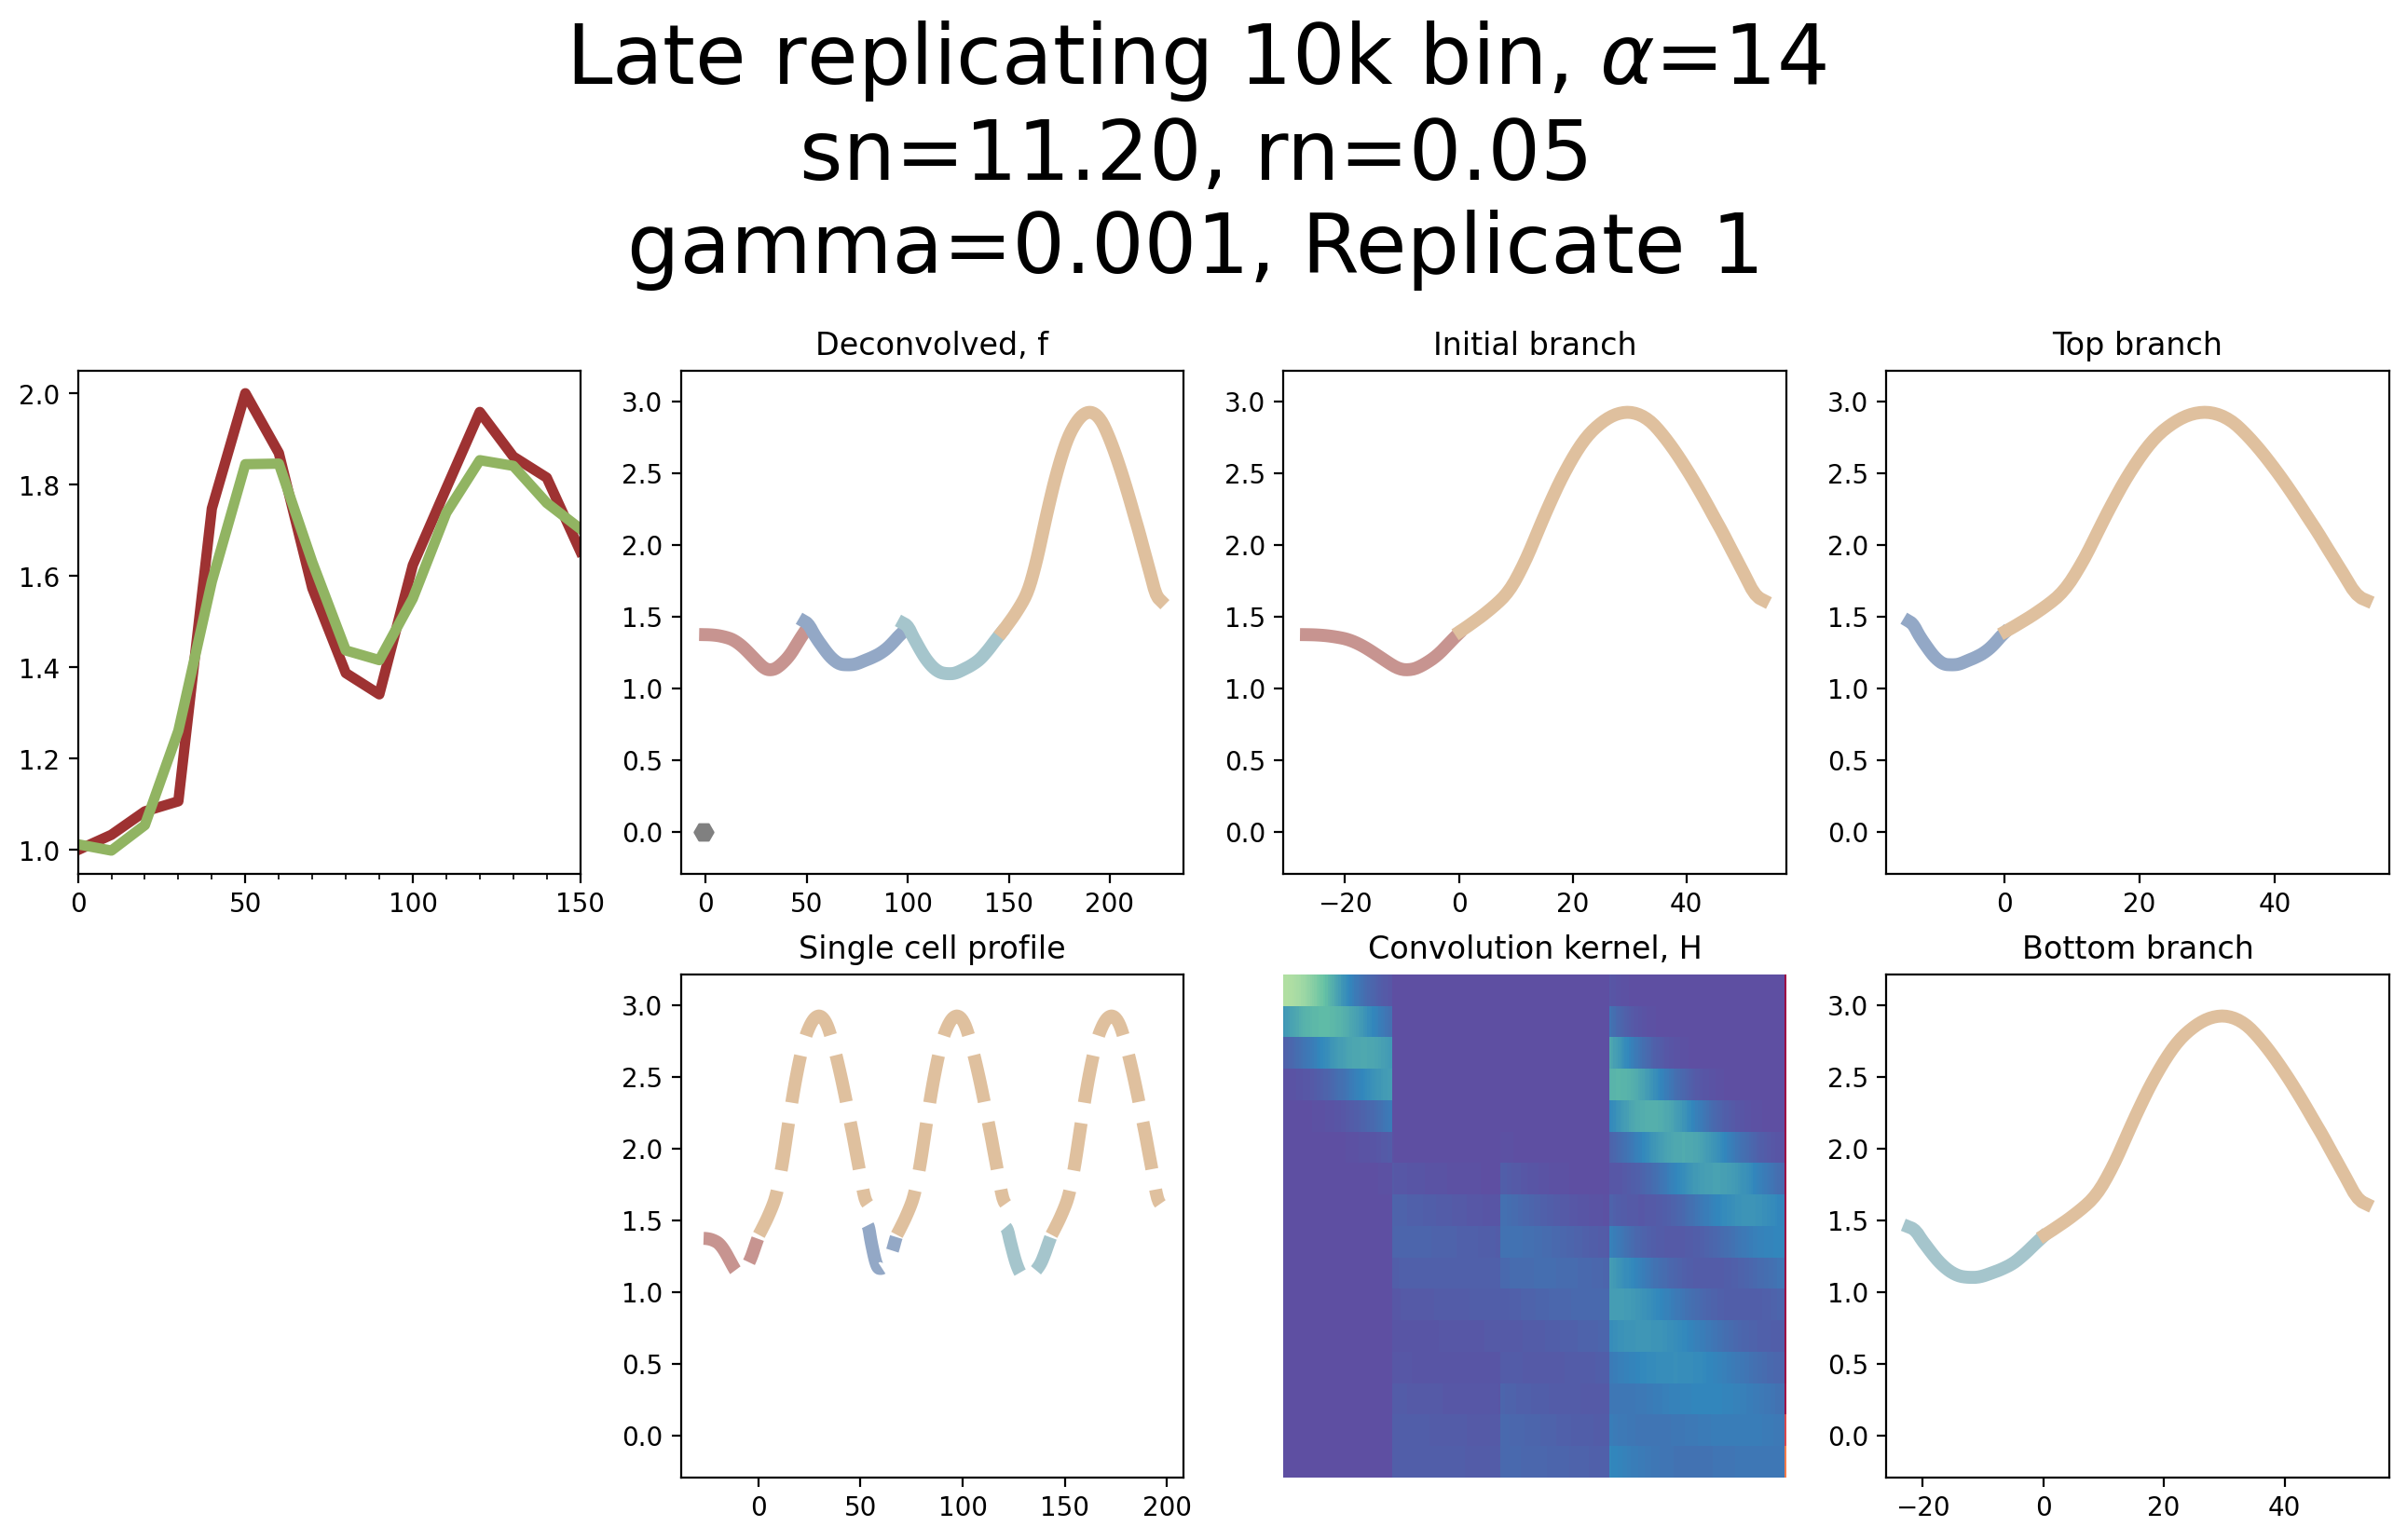

In [26]:
deconv_rep_analysis.compare_early_late_deconv_bin_curves(14, 1)

In [40]:
deconv_rep_analysis.create_chr_bin_curves(1, 4)

Loading MNase reads for YMR199W/CLN1...Loading chromosome reads: 13
Done.


In [ ]:
deconv_rep_analysis.alpha_search(alphas=[0, 14, 28])

0/3
Deconvolving with gamma=0.001, gamma_prime=0


Text(0.5, 0.98, 'Replicate 1, chromosome 4')

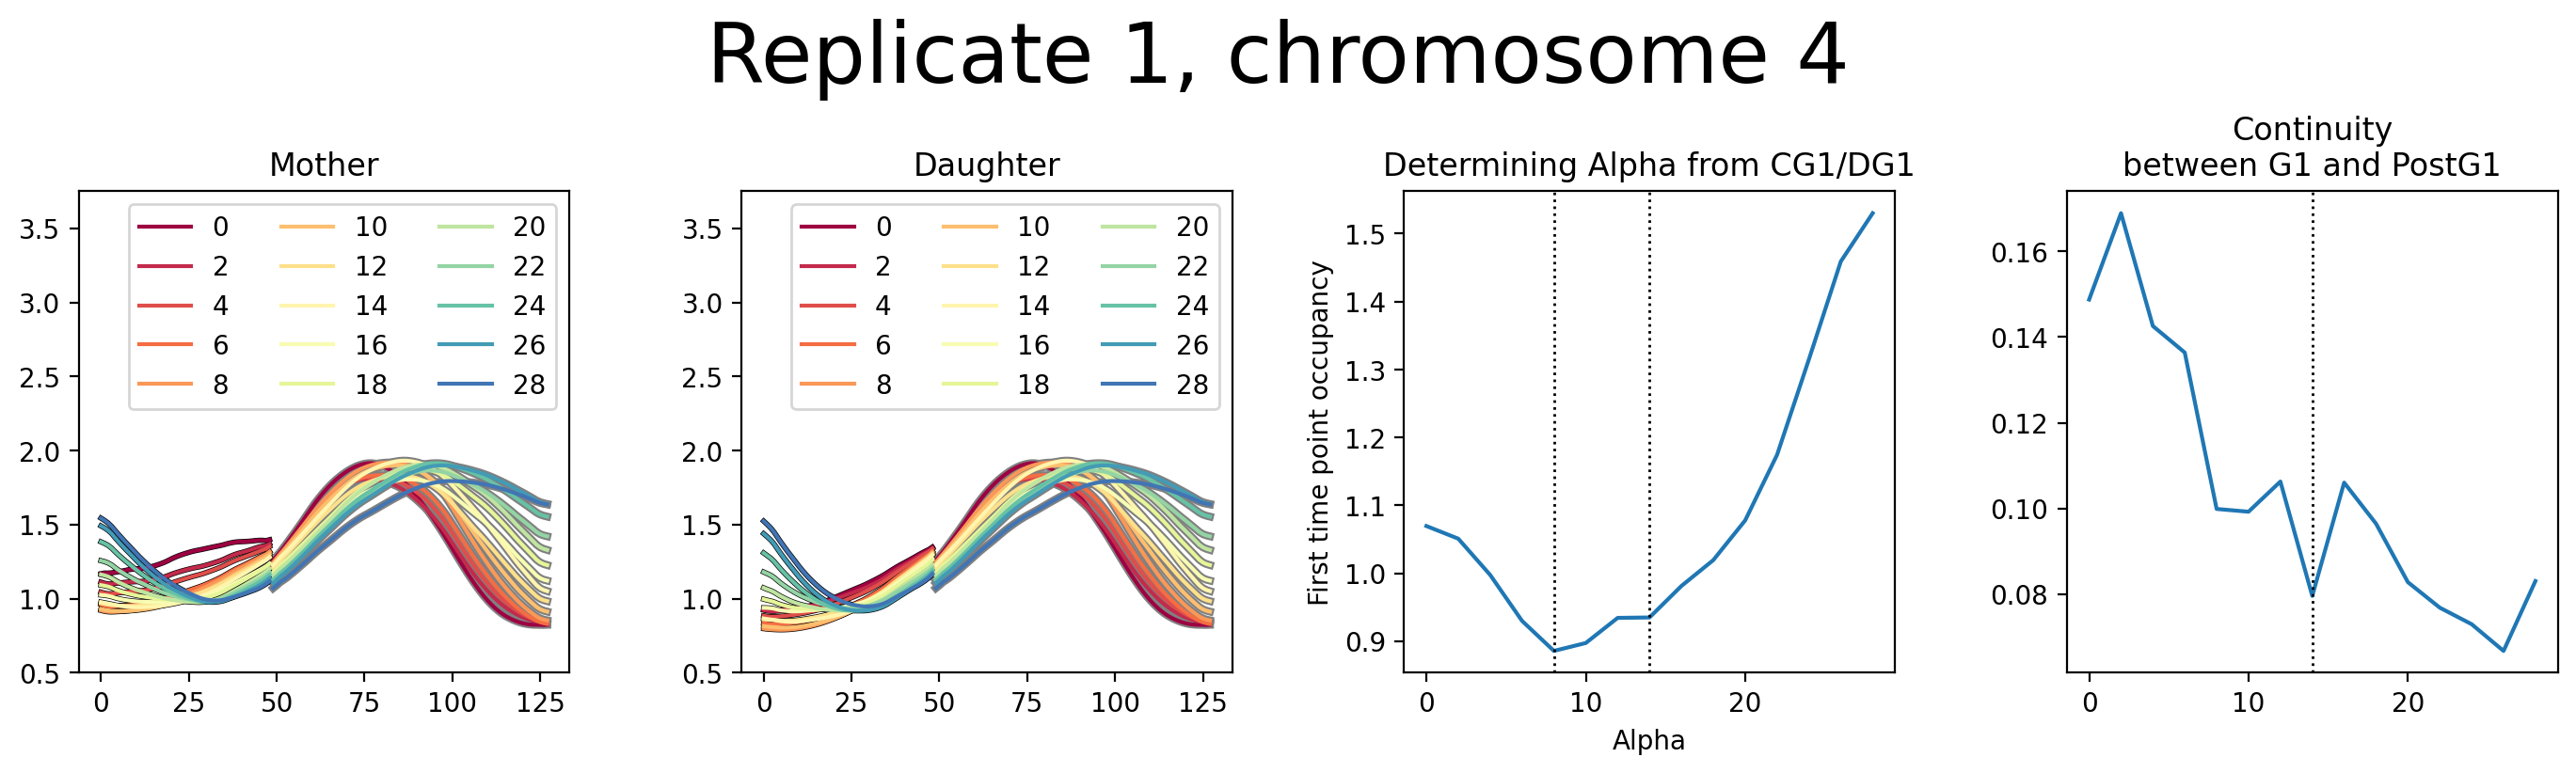

In [1101]:
# For indexing the result
i_indices = config.get_Hpositions_for_branch('i')
t_indices = config.get_Hpositions_for_branch('t')
b_indices = config.get_Hpositions_for_branch('b')
cg1_ind = config.get_Hpositions_for_phase('CG1')
dg1_ind = config.get_Hpositions_for_phase('DG1')
postG1_ind = config.get_Hpositions_for_phase('postG1')

def plot_alpha_avg(g1_indices, alpha_fs, i, alphas):
    color = plt.get_cmap('Spectral')(i/len(alphas))
    alpha = alphas[i]
    dg1 = alpha_fs[i][g1_indices].mean(axis=1)
    postg1 = alpha_fs[i][postG1_ind].mean(axis=1)
    
    plt.plot(np.arange(len(dg1)), dg1, c='black', lw=2, zorder=1)
    plt.plot(np.arange(len(postg1)) + len(dg1), postg1, c='gray', lw=3, zorder=1)
    
    plt.plot(np.arange(len(dg1)), dg1, c=color)
    plt.plot(np.arange(len(postg1)) + len(dg1), postg1, c=color, label=alpha)
    plt.ylim(0.5, 3.75)
    plt.legend(ncol=3)

plt.figure(figsize=(17, 4))
plt.subplot(1, 4, 1)
plt.subplots_adjust(wspace=0.35, top=0.75)

for i in range(len(alphas)):
    plot_alpha_avg(cg1_indices, alpha_fs, i, alphas)
plt.title("Mother")

plt.subplot(1, 4, 2)
for i in range(len(alphas)):
    plot_alpha_avg(dg1_indices, alpha_fs, i, alphas)
plt.title("Daughter")

mean_dg1 = np.median(alpha_fs[:, dg1_ind[0], :], axis=1)
mean_cg1 = np.median(alpha_fs[:, cg1_ind[0], :], axis=1)
avg_cg1_dg1 = (mean_dg1+mean_cg1)/2

plt.subplot(1, 4, 3)
plt.plot(alphas, avg_cg1_dg1, label="CG1/DG1 mean")

min_ind = np.argmin(mean_cg1)
min_alpha = alphas[min_ind]
plt.axvline(min_alpha, c='black', lw=1, ls='dotted')
plt.axvline(14, c='black', lw=1, ls='dotted')
plt.xlabel("Alpha")
plt.ylabel("First time point occupancy")
plt.title("Determining Alpha from CG1/DG1")

# The continuity from the end of CG1 to the start of PostG1
plt.subplot(1, 4, 4)
last_dg1 = np.median(alpha_fs[:, dg1_ind[-1], :], axis=1)
last_cg1 = np.median(alpha_fs[:, cg1_ind[-1], :], axis=1)
start_postg1 = np.median(alpha_fs[:, postg1_indices[0], :], axis=1)
cg1_dg1_post_g1_diff = (np.abs(last_dg1-start_postg1) + np.abs(last_cg1-start_postg1))/2.
plt.plot(alphas, cg1_dg1_post_g1_diff, label="DG1/CG1 and postG1")
plt.axvline(14, c='black', lw=1, ls='dotted')
plt.title("Continuity\nbetween G1 and PostG1")
plt.suptitle("Replicate 1, chromosome 4", fontsize=32)

In [1042]:

def plot_repl_prof_alpha_ind(ind):
    
    tps = config.get_timepoints_for_branch('t')
    
    plt.figure(figsize=(13, 4))

    alpha = alphas[ind]

    plt.subplot(2, 1, 1)
    plt.imshow(alpha_fs[ind][t_indices], origin='lower', 
               vmin=1, vmax=2, aspect='auto',
              extent=[0, 1000, tps[0], tps[-1]])
    plt.title("Mother")
    plt.xticks([])

    plt.subplot(2, 1, 2)
    plt.imshow(alpha_fs[ind][b_indices], origin='lower', vmin=1, vmax=2, aspect='auto',
              extent=[0, 1000, tps[0], tps[-1]])
    plt.title("Daughter")
    plt.xticks([])

    plt.suptitle(f"Deconvolved gene replication profile, chr4, replicate 1, alpha={alpha}")


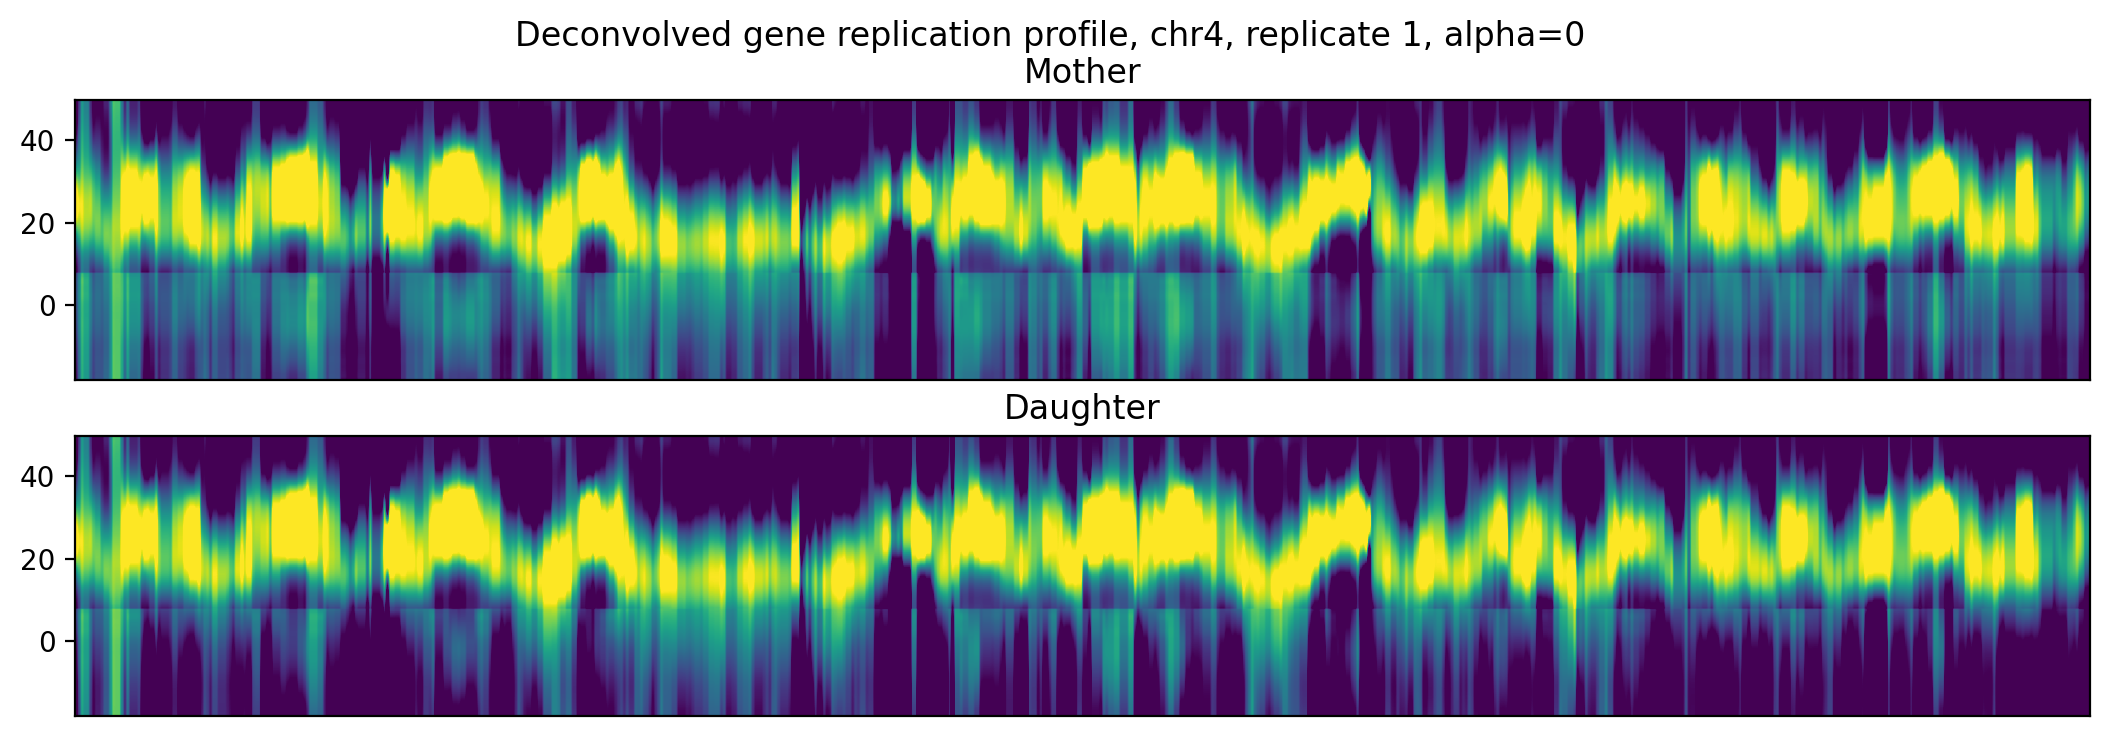

In [1061]:
plot_repl_prof_alpha_ind(0)

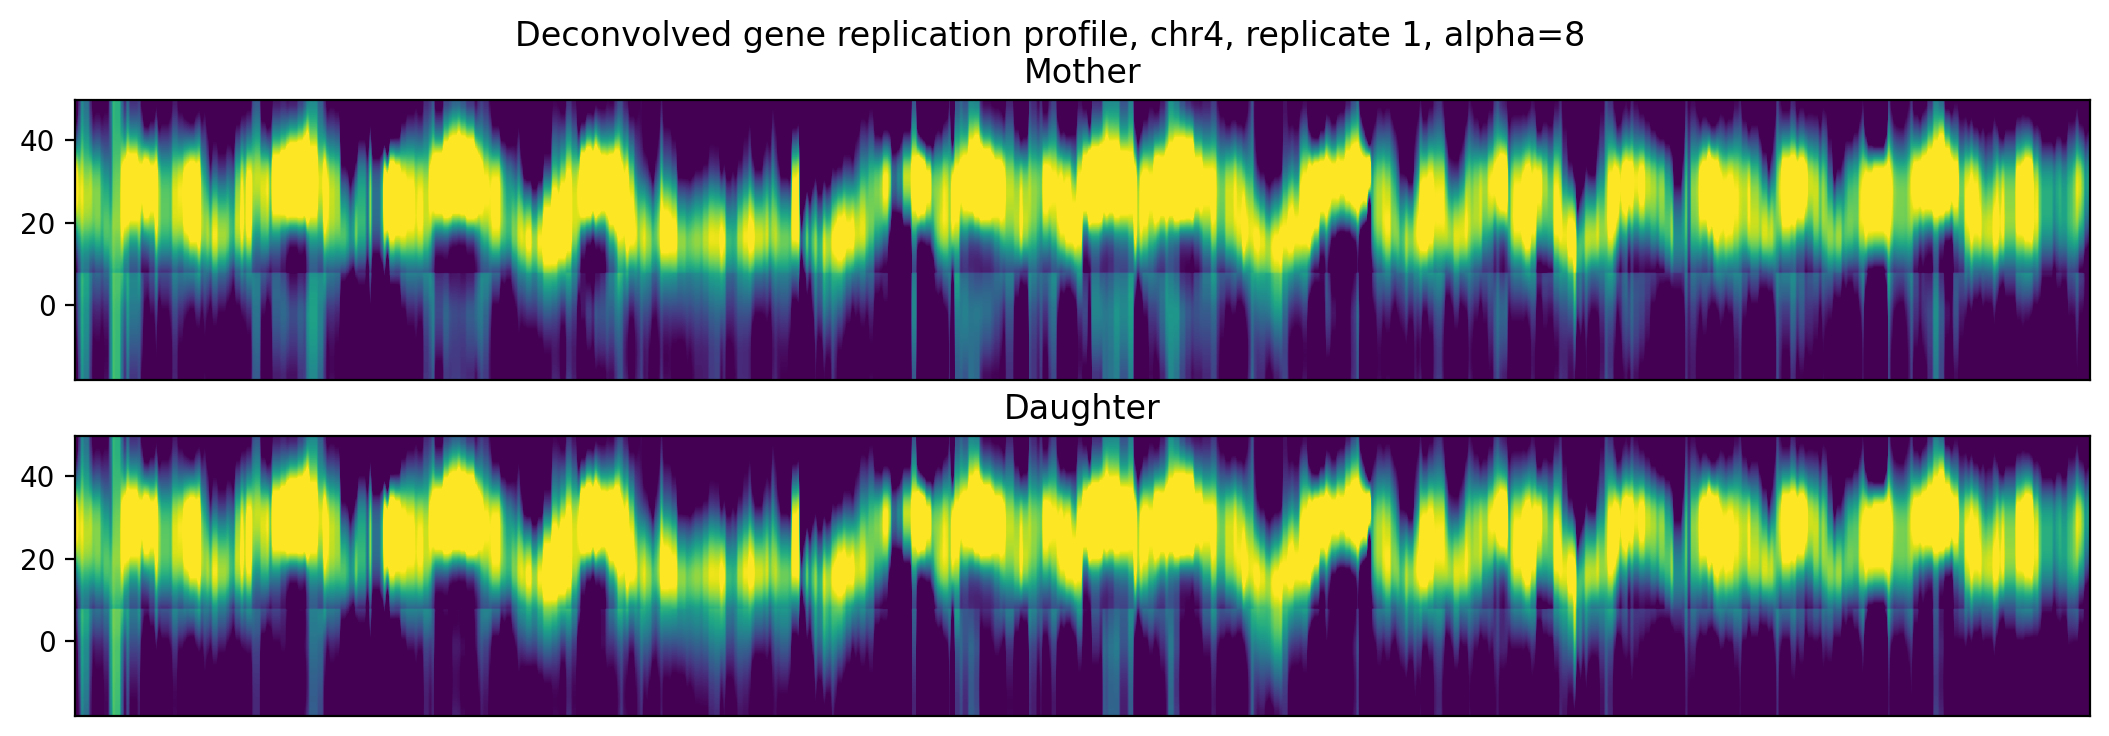

In [1043]:
plot_repl_prof_alpha_ind(min_ind)

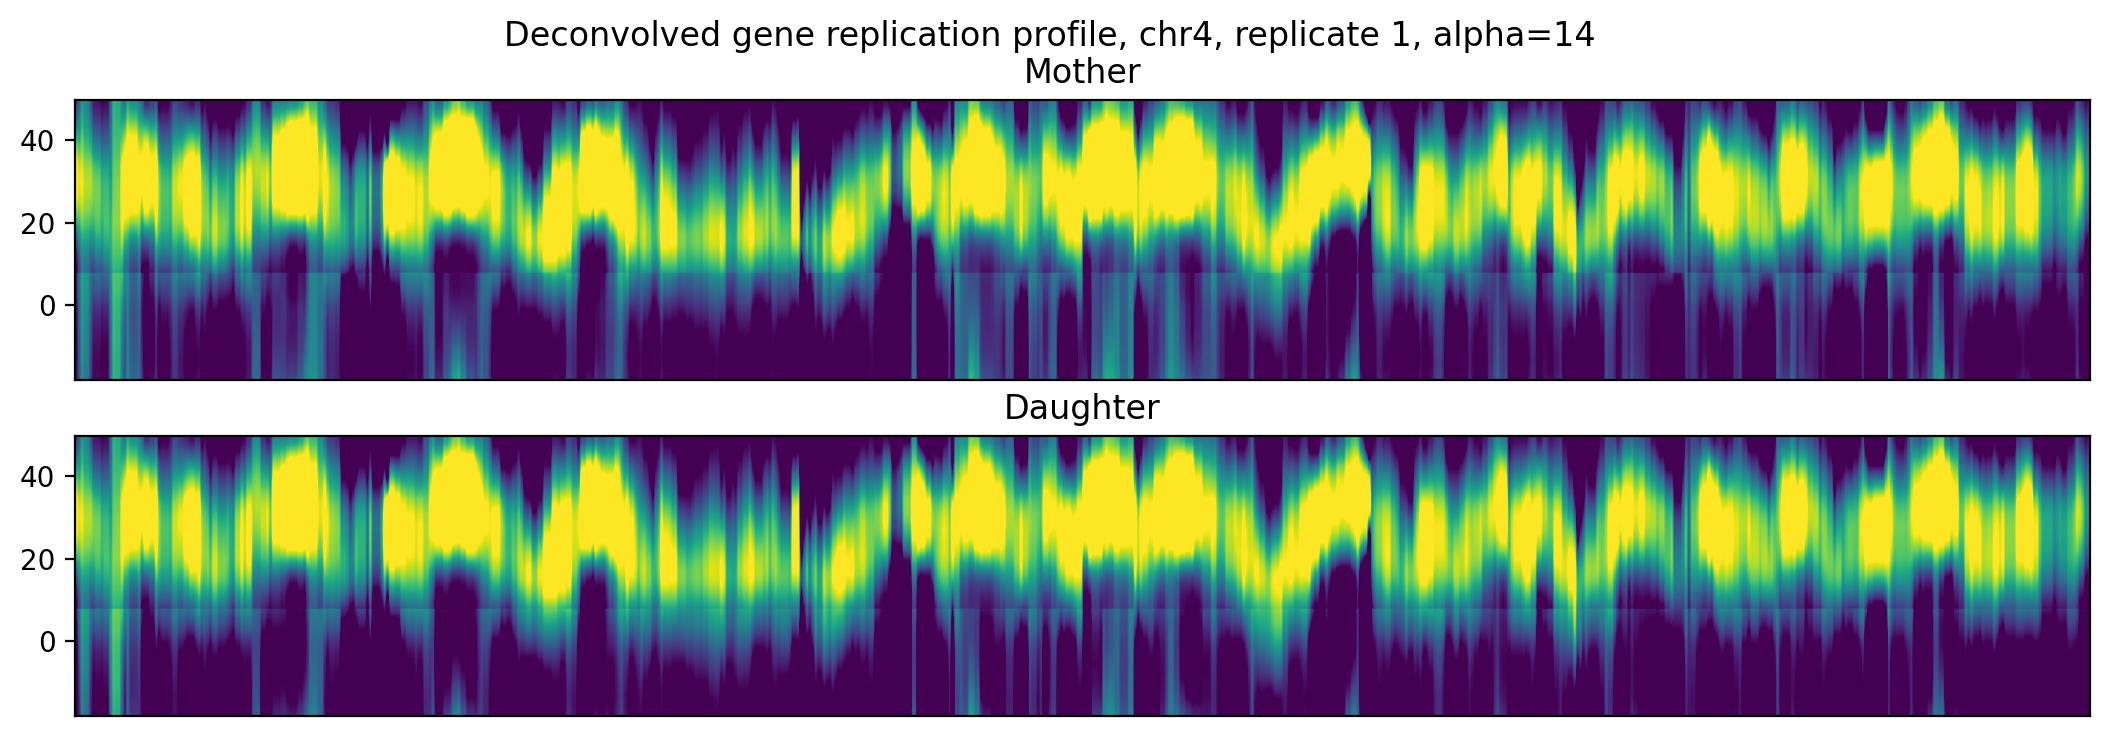

In [1057]:
plot_repl_prof_alpha_ind(7)

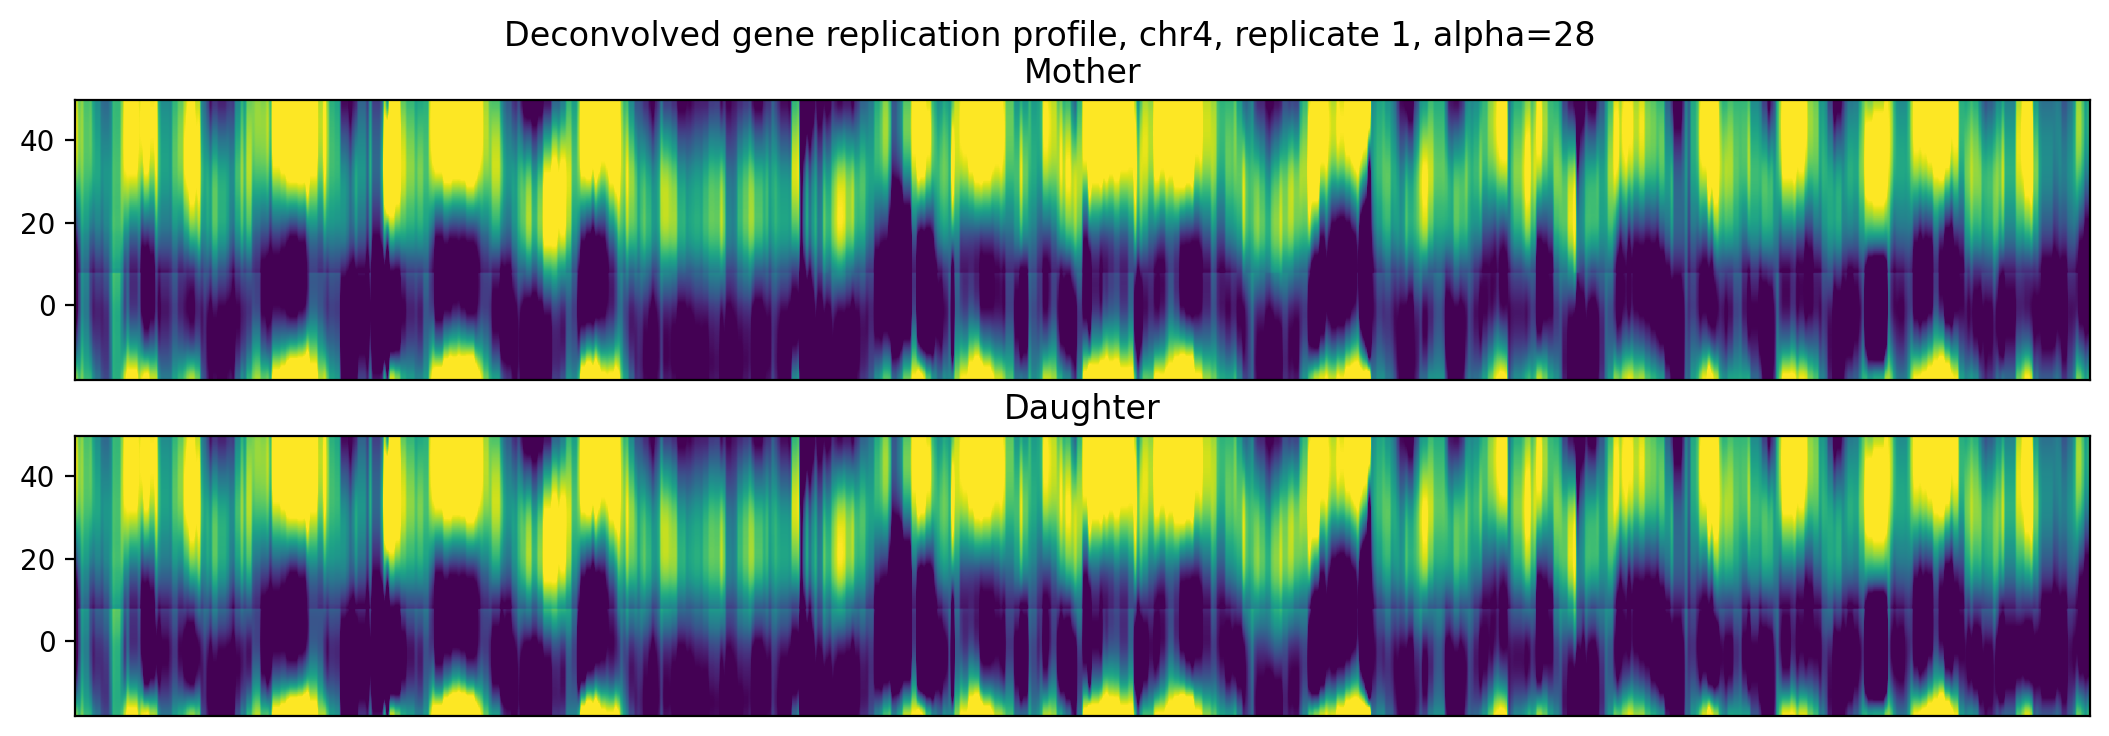

In [1064]:
plot_repl_prof_alpha_ind(14)